In [12]:
import os
import sys
import tempfile
import shutil

# Windows-only: ensure rtools and TBB are on PATH
os.environ['PATH'] += r';C:\rtools42\usr\bin;C:\rtools42\x86_64-w64-mingw32.static.posix\bin'

temp_dir = os.path.join(os.path.expanduser("~"), "cmdstan_tmp")
os.makedirs(temp_dir, exist_ok=True)
tempfile.tempdir = temp_dir
os.environ["TMPDIR"] = temp_dir
os.environ["TEMP"] = temp_dir
os.environ["TMP"] = temp_dir

import cmdstanpy
import cmdstanpy.utils.filesystem as fs
fs._TMPDIR = temp_dir  

cmdstan_path = cmdstanpy.cmdstan_path()
os.environ['PATH'] += f';{cmdstan_path}/stan/lib/stan_math/lib/tbb'

import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sys.path.append(os.path.abspath(".."))
from analogues import AnalogueSample, SelectionConfig, FilterConfig

## Stan Hierarchical Model

Two Stan models are defined below: one fit on the full dataset (for inference and LG prediction)
and one with a train/test split (for held-out validation). In this notebook the features used will be Bell-corrected total K-band stellar mass, K-band stellar mass ratio, radial velocity and separation.

In [13]:
stan_code = """
data {
    int<lower=0> N;
    array[N] int<lower=1, upper=2> group;
    matrix[N, 4] X;          // standardized: v_r, sep, mass_ratios and total K Band luminosity
    vector[N] y;              // log M200c
    vector[4] x_lg;
}

parameters {
    real mu_alpha;
    real<lower=0> sigma_alpha;
    vector[4] mu_beta;
    
    vector[2] alpha_raw;
    vector<lower=0>[4] sigma_beta;
    matrix[2, 4] beta_raw;
    
    real<lower=1e-3> sigma;
}

transformed parameters {
    vector[2] alpha;
    matrix[2,4] beta;
    vector[N] eta;

    alpha = mu_alpha + sigma_alpha * alpha_raw;

    for (g in 1:2) {
        for (k in 1:4) {
            beta[g, k] = mu_beta[k] + sigma_beta[k] * beta_raw[g, k];
        }
    }

    for (n in 1:N) {
        eta[n] = alpha[group[n]] + dot_product(beta[group[n]], X[n]);
        // eta[n] = fmin(fmax(eta[n], -20), 20);
    }
}

model {
    alpha_raw ~ normal(0, 1);
    to_vector(beta_raw) ~ normal(0, 1);
    
    mu_alpha ~ normal(12.6, 0.2);     // (3.17+-0.57) x10^12 ~LogM ~ 12.5 van der Marel et al. (2012)

    // Blue-blue peaks at 12-12.5, red-red extends to 13.8 (baryon efficiency plot from EDA)
    // Expecting ~0.3-0.5 dex difference between groups
    sigma_alpha ~ exponential(2);  // The blue-blue and red-red intercepts are expected to differ by at most 0.2-0.3 dex based on the baryon efficiency plot from EDA, with the prior centered to reflect this modest group-level variation.

    // Using weakly informed prior centered at zero to allow the data to determine both the direction and magnitude of the effect.
    mu_beta[1] ~ normal(0.0, 0.2);   // v_r coefficient no strong prior K statistics show some relevance but didn't find any literature conirming this

    mu_beta[2] ~ normal(0.0, 0.2);   // seperation coefficient: No strong theoretical expectation that pair separation directly determines halo mass

    mu_beta[3] ~ normal(0.0, 0.2);   // analogous to mass ratio k band ratio weak prior

    // A moderately positive prior centered around 0.3 is adopted, allowing for uncertainty while avoiding unrealistically steep scaling.
    mu_beta[4] ~ normal(0.3, 0.2);   // total K band luminosity: Total K band Luminosity is expected to correlate positively with halo mass. Same direction expected as stellar mass

    // group variation in coefficients
    // Does not allow extreme differences but only small ones which makes sense from EDA
    sigma_beta ~ exponential(10);    // half-normal effectively since sigma_beta > 0
    // Residual scatter truncated to only be positive
    // From Moser et al (2013)
    sigma ~ normal(0.3, 0.1); // obs scatter is between 0.15 intrinsic physical scatter from the above resource. We choose slightly higher value
    
    for (n in 1:N) {
        y[n] ~ normal(eta[n], sigma);
    }
       
}

generated quantities {
    vector[N] y_rep;
    vector[N] log_lik; 
    vector[N] eta_rep;
    real y_lg_bb;
    real y_lg_rr; 

    // LG predictions 
    y_lg_bb = normal_rng(alpha[1] + dot_product(beta[1], x_lg), sigma);
    y_lg_rr = normal_rng(alpha[2] + dot_product(beta[2], x_lg), sigma);

    for (n in 1:N) {
        y_rep[n] = normal_rng(
            alpha[group[n]] + dot_product(beta[group[n]], X[n]),
            sigma
        );
        log_lik[n] = normal_lpdf(y[n] | 
            alpha[group[n]] + dot_product(beta[group[n]], X[n]),
            sigma
        );  
    }


    for (n in 1:N) {
        eta_rep[n] = alpha[group[n]] + dot_product(beta[group[n]], X[n]);
    }
}
"""

In [14]:
stan_code_2 = """
data {
    int<lower=0> N_train;
    int<lower=0> N_test;
    array[N_train] int<lower=1, upper=2> group_train;
    array[N_test] int<lower=1, upper=2> group_test;
    matrix[N_train, 4] X_train;
    matrix[N_test, 4] X_test;
    vector[N_train] y_train;
    vector[4] x_lg;
}

parameters {
    real mu_alpha;
    real<lower=0> sigma_alpha;
    vector[4] mu_beta;
    vector<lower=0>[4] sigma_beta;
    
    vector[2] alpha_raw;
    matrix[2, 4] beta_raw;
    
    real<lower=1e-3> sigma;
}

transformed parameters {
    vector[2] alpha;
    matrix[2,4] beta;

    alpha = mu_alpha + sigma_alpha * alpha_raw;

    for (g in 1:2) {
        for (k in 1:4) {
            beta[g, k] = mu_beta[k] + sigma_beta[k] * beta_raw[g, k];
        }
    }
}

model {
    alpha_raw ~ normal(0, 1);
    to_vector(beta_raw) ~ normal(0, 1);
    
    mu_alpha ~ normal(12.6, 0.2);
    sigma_alpha ~ exponential(2);
    
    mu_beta[1] ~ normal(0.0, 0.2);
    mu_beta[2] ~ normal(0.0, 0.2);
    mu_beta[3] ~ normal(0.0, 0.2);
    mu_beta[4] ~ normal(0.3, 0.2);

    sigma_beta ~ exponential(10);
    sigma ~ normal(0.3, 0.1);
    
    for (n in 1:N_train)
        y_train[n] ~ normal(
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
}

generated quantities {
    vector[N_train] y_rep_train;
    vector[N_train] log_lik;
    vector[N_test] y_rep_test;
    real y_lg_bb;
    real y_lg_rr;

    for (n in 1:N_train) {
        y_rep_train[n] = normal_rng(
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
        log_lik[n] = normal_lpdf(y_train[n] |
            alpha[group_train[n]] + dot_product(beta[group_train[n]], X_train[n]),
            sigma
        );
    }
    
    for (n in 1:N_test) {
        y_rep_test[n] = normal_rng(
            alpha[group_test[n]] + dot_product(beta[group_test[n]], X_test[n]),
            sigma
        );
    }

    y_lg_bb = normal_rng(alpha[1] + dot_product(beta[1], x_lg), sigma);
    y_lg_rr = normal_rng(alpha[2] + dot_product(beta[2], x_lg), sigma);
}
"""

## 1. Build Analogue Sample

The `AnalogueSample` class replaces the old manual pipeline of separate calls to
`load_header_constants`, `select_central_plus_largest_satellite_by_stellar_mass`,
`find_pairs_periodic`, and the individual isolation/velocity filter functions.
All configuration is now passed declaratively via `SelectionConfig` and `FilterConfig`.

In [15]:
base_path = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")  

selection_config = SelectionConfig(
    m_stellar_min=2e10,    # M_sun
    m_stellar_max=5e11,    # M_sun
    r_min=500.0,           # kpc
    r_max=1000.0,          # kpc
    blue_threshold_gr=0.65
)

filter_config = FilterConfig(
    vt_min=0,              # km/s
    vt_max=300,            # km/s
    vr_min=-400,           # km/s
    vr_max=0,              # km/s
    v_tot_min=0,           # km/s
    v_tot_max=500,         # km/s
    third_massive_factor=1.5,
    density_radius=2000,   # kpc 
    intruder_factor=0.5,
)

analogue_sample = AnalogueSample(
    base_path=base_path,
    selection_config=selection_config,
    filter_config=filter_config,
    snap=99,
    verbose=True,
)


[DIAGNOSTIC] Simulation Header Constants
╒════════════╤═══════════╤═══════════════╕
│ Parameter  │ Value     │ Units         │
├────────────┼───────────┼───────────────┤
│ Hubble (h) │ 0.6774    │ dimensionless │
├────────────┼───────────┼───────────────┤
│ Box Side   │ 302627.69 │ kpc           │
╘════════════╧═══════════╧═══════════════╛

[DIAGNOSTIC] Sample Selection
╒═════════════════════════════════════════╤══════════╤═════════════════╕
│ Selection Step                          │    Count │ Yield           │
╞═════════════════════════════════════════╪══════════╪═════════════════╡
│ Total Subhalos in Catalog               │ 14485709 │ 100.0%          │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Passed Quality Flags (SubhaloFlag==1)   │  1902558 │ 13.1%           │
├─────────────────────────────────────────┼──────────┼─────────────────┤
│ Inside Stellar Mass Window              │    60562 │ 3.2% of good    │
├─────────────────────────────────────────

## 2. Extract Pairs and Build Feature Matrix

All pair properties are now stored in `PairSet`. Photometry is accessed via
`sample.g_band` / `sample.r_band` (pre-extracted in `Sample`), so the manual
`sub['SubhaloStellarPhotometrics'][sample.keep_idx]` indexing is no longer needed.
Mixed (blue-red) pairs are dropped; only pure blue-blue and red-red pairs are retained.

In [16]:
pairs = analogue_sample.pairs


sample = analogue_sample._sample  

i = pairs.i
j = pairs.j

# Keep only pure pairs (blue-blue or red-red)
keep_pure = pairs.is_blue_blue | pairs.is_red_red

i_f = i[keep_pure]
j_f = j[keep_pure]

# g-r color per member (already stored in Sample)
g_r_1 = sample.g_band[i_f] - sample.r_band[i_f]
g_r_2 = sample.g_band[j_f] - sample.r_band[j_f]

bb_f = (g_r_1 < selection_config.blue_threshold_gr) & (g_r_2 < selection_config.blue_threshold_gr)
rr_f = (g_r_1 >= selection_config.blue_threshold_gr) & (g_r_2 >= selection_config.blue_threshold_gr)

# Stellar masses (M_sun)
h = analogue_sample._selection_config.hubble_param
Mi_star = sample.m_stellar[i_f]
Mj_star = sample.m_stellar[j_f]

# K Band
Ki = sample.k_band[i_f]
Kj = sample.k_band[j_f]

# Have to do Bell's correction
log_Mtot_kband = np.log10(
    10**((-0.206 + 0.138 * g_r_1) + (-0.4 * (Ki - 3.28))) +
    10**((-0.206 + 0.138 * g_r_2) + (-0.4 * (Kj - 3.28)))
)

# log_ktot = -2.5 * np.log10(10**(-0.4 * Ki) + 10**(-0.4 * Kj)) without bell's correction

k_ratio = np.abs(
    ((-0.206 + 0.138 * g_r_1) + (-0.4 * (Ki - 3.28))) -
    ((-0.206 + 0.138 * g_r_2) + (-0.4 * (Kj - 3.28)))
)  # log M* ratio, analogous to mass_ratio

# k_ratio  = np.abs(Ki - Kj) / 2.5

# Derived features
g_r_mean      = (g_r_1 + g_r_2) / 2
mass_ratio    = np.abs(np.log10(Mi_star / Mj_star))
log_Mtot_star = np.log10(Mi_star + Mj_star)
vr_f          = pairs.vr[keep_pure]
vt_f          = pairs.vt[keep_pure]
sep_f         = pairs.separation[keep_pure]

features = np.column_stack([vr_f, sep_f,k_ratio, log_Mtot_kband])

# Target: mean log M200c of the pair (M_sun)
log_m200c = 0.5 * (
    np.log10(sample.m200c[i_f]) +
    np.log10(sample.m200c[j_f])
)

# Group labels: 1 = blue-blue, 2 = red-red
group = np.where(bb_f, 1, 2).astype(int)

print(f'Pure pairs: {keep_pure.sum()}')
print(f'  Blue-blue: {bb_f.sum()}')
print(f'  Red-red:   {rr_f.sum()}')
print(f'mass_ratio range:    {mass_ratio.min():.2f} to {mass_ratio.max():.2f}')
print(f'log M200c range:     {log_m200c.min():.2f} to {log_m200c.max():.2f}')

Pure pairs: 1072
  Blue-blue: 165
  Red-red:   907
mass_ratio range:    0.00 to 1.19
log M200c range:     11.69 to 13.87


## 3. Standardise Features and Encode LG Observables

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

feat_mean = scaler.mean_
feat_std  = scaler.scale_

print('Column means (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Column stds  (should be ~1):', X_scaled.std(axis=0).round(4))
print('Max |z| per column:', np.max(np.abs(X_scaled), axis=0).round(2))

log_Mstar_mw  = (-0.206 + 0.138 * 0.53) + (-0.4 * (-23.3 - 3.28))
log_Mstar_m31 = (-0.206 + 0.138 * 0.63) + (-0.4 * (-24.0 - 3.28))

# Real Local Group observables with Bell's correction
lg_obs_raw = np.array([                           
    -109.3,                           # v_r [km/s]
    765.0,                            # separation [kpc]
    np.abs(log_Mstar_mw - log_Mstar_m31),    # K band ratio
    np.log10(10**log_Mstar_mw + 10**log_Mstar_m31),            # log total K band
])

# lg_obs_raw = np.array([
#     -109.3,                                                              # v_r [km/s]
#     765.0,                                                               # separation [kpc]
#     np.abs(-23.3 - (-24.0)) / 2.5,                                      # k_ratio
#     -2.5 * np.log10(10**(-0.4 * -23.3) + 10**(-0.4 * -24.0)),          # log_ktot
# ])

lg_obs_scaled = (lg_obs_raw - feat_mean) / feat_std

print(f'\nLG obs max |z|: {np.max(np.abs(lg_obs_scaled)):.3f}  (should be < 3)')
assert np.all(np.isfinite(X_scaled)), 'Non-finite values in X_scaled'
assert np.all(np.isfinite(log_m200c)), 'Non-finite values in log_m200c'

Column means (should be ~0): [ 0. -0.  0.  0.]
Column stds  (should be ~1): [1. 1. 1. 1.]
Max |z| per column: [2.55 1.73 3.36 2.76]

LG obs max |z|: 0.681  (should be < 3)


## 4. Compile Stan Models

In [18]:
import hashlib

def write_if_changed(filename, code):
    new_hash = hashlib.md5(code.encode()).hexdigest()
    try:
        with open(filename + '.md5', 'r') as f:
            old_hash = f.read()
        if old_hash == new_hash:
            return False  
    except FileNotFoundError:
        pass
    with open(filename, 'w') as f:
        f.write(code)
    with open(filename + '.md5', 'w') as f:
        f.write(new_hash)
    return True  

write_if_changed('hierarchical_model_Kband1.stan', stan_code)
model = cmdstanpy.CmdStanModel(stan_file='hierarchical_model_Kband1.stan')

write_if_changed('hierarchical_model_2_Kband2.stan', stan_code_2)
model_2 = cmdstanpy.CmdStanModel(stan_file='hierarchical_model_2_Kband2.stan')

## Prior Predictive Checks

Important that likelihood was commented out in the stan model to ensure that priors chosen are reasonable.

In [19]:
# # Stan data dictionary
# stan_data = {
#     "N": int(X_scaled.shape[0]),
#     "group": group.tolist(),
#     "X": X_scaled.tolist(),
#     "y": log_m200c.tolist()
# }

# # Sample from prior only (likelihood commented out)
# fit_prior = model.sample(
#     data=stan_data,
#     chains=4,
#     iter_sampling=500,
#     iter_warmup=500,
#     show_progress=True
# )

# print(fit_prior.summary())


In [20]:
# import arviz as az
# import matplotlib.pyplot as plt

# idata_prior = az.from_cmdstanpy(fit_prior)

# # Extract prior predictive samples
# y_prior = fit_prior.stan_variable("y_rep")

# fig, ax = plt.subplots(figsize=(9, 5))

# # Prior predictive distribution
# ax.hist(y_prior.flatten(), bins=50, density=True,
#         color='blue', alpha=0.4, label='Prior predictive')

# # Actual data distribution
# ax.hist(log_m200c, bins=30, density=True,
#         color='red', alpha=0.4, label='Actual data')

# # Reference lines
# ax.axvline(12.5, color='black', linestyle='--', 
#            linewidth=2, label='Real LG ~12.5')
# ax.axvline(log_m200c.mean(), color='red', linestyle='-',
#            linewidth=1, label=f'Data mean={log_m200c.mean():.2f}')

# ax.set_xlabel('log M200c [Msun]')
# ax.set_ylabel('Density')
# ax.set_title('Prior Predictive Check')
# ax.legend()
# ax.set_xlim(10, 15)
# plt.tight_layout()
# plt.show()

# print(f"Prior predictive mean: {y_prior.mean():.2f}")
# print(f"Prior predictive std: {y_prior.std():.2f}")
# print(f"Prior predictive 2.5%: {np.percentile(y_prior, 2.5):.2f}")
# print(f"Prior predictive 97.5%: {np.percentile(y_prior, 97.5):.2f}")
# print(f"\nActual data mean: {log_m200c.mean():.2f}")
# print(f"Actual data std: {log_m200c.std():.2f}")
# print("Data range:", log_m200c.min(), log_m200c.max())
# print("Prior range:", y_prior.min(), y_prior.max())

## 5. Full-Data Posterior Fit

In [21]:
stan_data = {
    'N':     int(X_scaled.shape[0]),
    'group': group.tolist(),
    'X':     X_scaled.tolist(),
    'y':     log_m200c.tolist(),
    'x_lg':  lg_obs_scaled.tolist(),
}

# fit = model.sample(
#     data=stan_data,
#     chains=4,
#     parallel_chains=4,
#     iter_sampling=1000,
#     iter_warmup=2000,
#     adapt_delta=0.999,
#     max_treedepth=15,
#     show_progress=True,
# )

# eta_samples = fit.stan_variable('eta')
# print('Any inf/nan in posterior eta:', np.any(~np.isfinite(eta_samples)))

os.makedirs("saved_fits/modelkband_1", exist_ok=True)

if os.path.exists("saved_fits/modelkband_1") and any(
    f.endswith(".csv") for f in os.listdir("saved_fits/modelkband_1")
):
    print("Loading saved model 1...")
    fit = from_csv("saved_fits/modelkband_1/")
    print("Loaded!")
else:
    print("Fitting model 1...")
    fit = model.sample(
        data=stan_data,
        chains=4,
        parallel_chains=4,
        iter_sampling=1000,
        iter_warmup=2000,
        adapt_delta=0.999,
        max_treedepth=15,
        show_progress=True,
    )
    for f in fit.runset.csv_files:
        shutil.copy(f, "saved_fits/modelkband_1/")
    print("Fitted and saved!")

eta_samples = fit.stan_variable('eta')
print('Any inf/nan in posterior eta:', np.any(~np.isfinite(eta_samples)))

18:10:34 - cmdstanpy - INFO - CmdStan start processing


Fitting model 1...


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]








chain 1:  33%|███▎      | 1000/3000 [02:37<04:21,  7.65it/s, (Warmup)]

chain 1:  50%|█████     | 1500/3000 [03:40<03:10,  7.87it/s, (Warmup)]

chain 1:  53%|█████▎    | 1600/3000 [03:52<02:54,  8.04it/s, (Warmup)]

chain 1:  60%|██████    | 1800/3000 [04:17<02:29,  8.00it/s, (Warmup)]



chain 1:  63%|██████▎   | 1900/3000 [04:30<02:19,  7.90it/s, (Warmup)]

chain 1:  67%|██████▋   | 2000/3000 [04:48<02:23,  6.98it/s, (Sampling)]

chain 1:  70%|███████   | 2100/3000 [05:05<02:15,  6.66it/s, (Sampling)]



chain 1:  73%|███████▎  | 2200/3000 [05:22<02:06,  6.35it/s, (Sampling)]


chain 1:  77%|███████▋  | 2300/3000 [05:39<01:53,  6.18it/s, (Sampling)]



chain 1:  80%|████████  | 2400/3000 [05:55<01:36,  6.20it/s, (Sampling)]

chain 1:  83%|████████▎ | 2500/3000 [06:13<01:22,  6.04it/s, (Sampling)]

chain 1:  87%|████████▋ | 2600/3000 [06:28<01:04,  6.16it/s, (Sampling)]




chain 1:  90%|█████████ | 2700/3000 [06:45<0


18:21:49 - cmdstanpy - INFO - CmdStan done processing.
18:21:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
	Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
	Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_Kband1.stan', line 69, column 8 to column 37)
	Exception: normal_lpdf: Loc


Fitted and saved!
Any inf/nan in posterior eta: False


## 6. Convergence Diagnostics

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Max R-hat: 1.0039  (should be < 1.01)
Min ESS:   1047  (should be > 400)
All R-hats < 1.01 — good convergence ✓


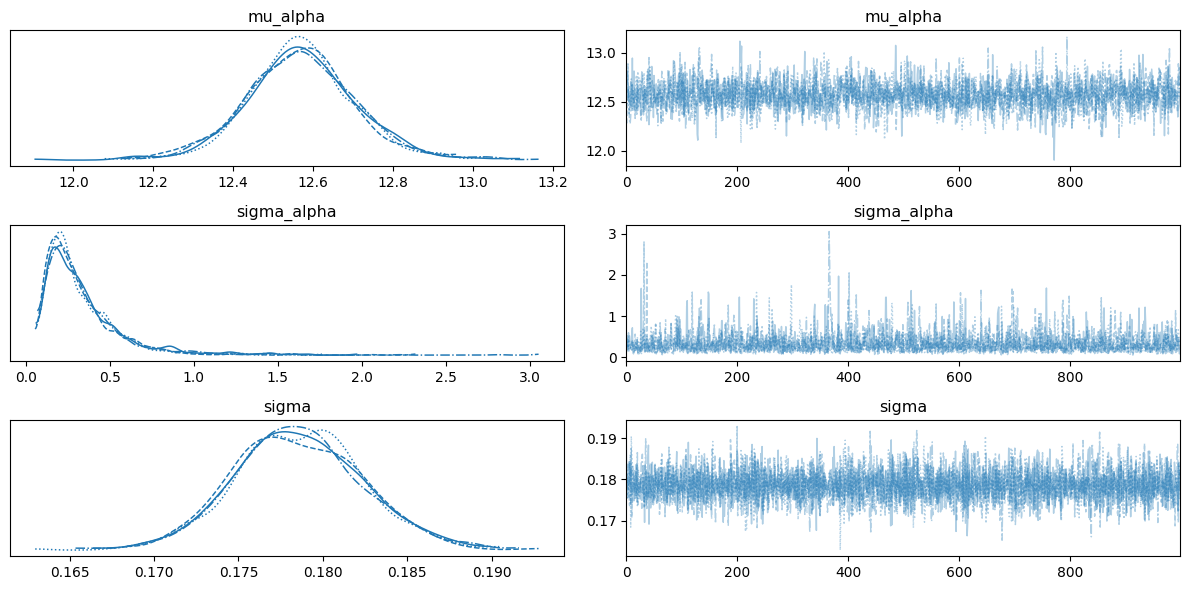

In [22]:
print(fit.diagnose())

summary = fit.summary()
print(f"Max R-hat: {summary['R_hat'].max():.4f}  (should be < 1.01)")
print(f"Min ESS:   {summary['ESS_bulk'].min():.0f}  (should be > 400)")

bad = summary[summary['R_hat'] > 1.01]
if len(bad):
    print('WARNING — Parameters with R-hat > 1.01:')
    print(bad[['R_hat', 'ESS_bulk']])
else:
    print('All R-hats < 1.01 — good convergence ✓')

idata = az.from_cmdstanpy(
    fit,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
    observed_data={'y': log_m200c},
)
az.plot_trace(idata, var_names=['mu_alpha', 'sigma_alpha', 'sigma'])
plt.tight_layout()
plt.show()

In [23]:
print("Model 1 diagnostics")
print(fit.diagnose())

summary_1 = fit.summary()
print(summary_1.sort_values('R_hat', ascending=False).head(10)[['R_hat', 'ESS_bulk']])

Model 1 diagnostics
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

                 R_hat  ESS_bulk
sigma_beta[2]  1.00395   1046.57
beta[2,3]      1.00381   3861.85
log_lik[615]   1.00333   4772.49
lp__           1.00329   1159.29
eta_rep[400]   1.00326   3945.33
eta[400]       1.00326   3945.33
eta_rep[158]   1.00322   3921.70
eta[158]       1.00322   3921.70
sigma_beta[1]  1.00305   1545.73
log_lik[1010]  1.00305   4021.53


## 7. Posterior Predictive Check

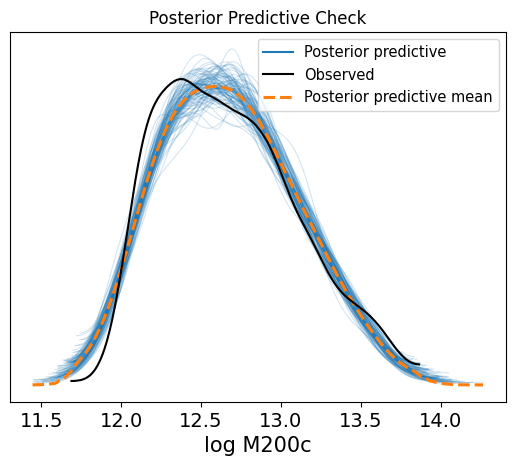

In [24]:
az.plot_ppc(idata, data_pairs={'y': 'y_rep'}, num_pp_samples=100)
plt.title('Posterior Predictive Check')
plt.xlabel('log M200c')
plt.show()

## 8. In-Sample Fit Quality

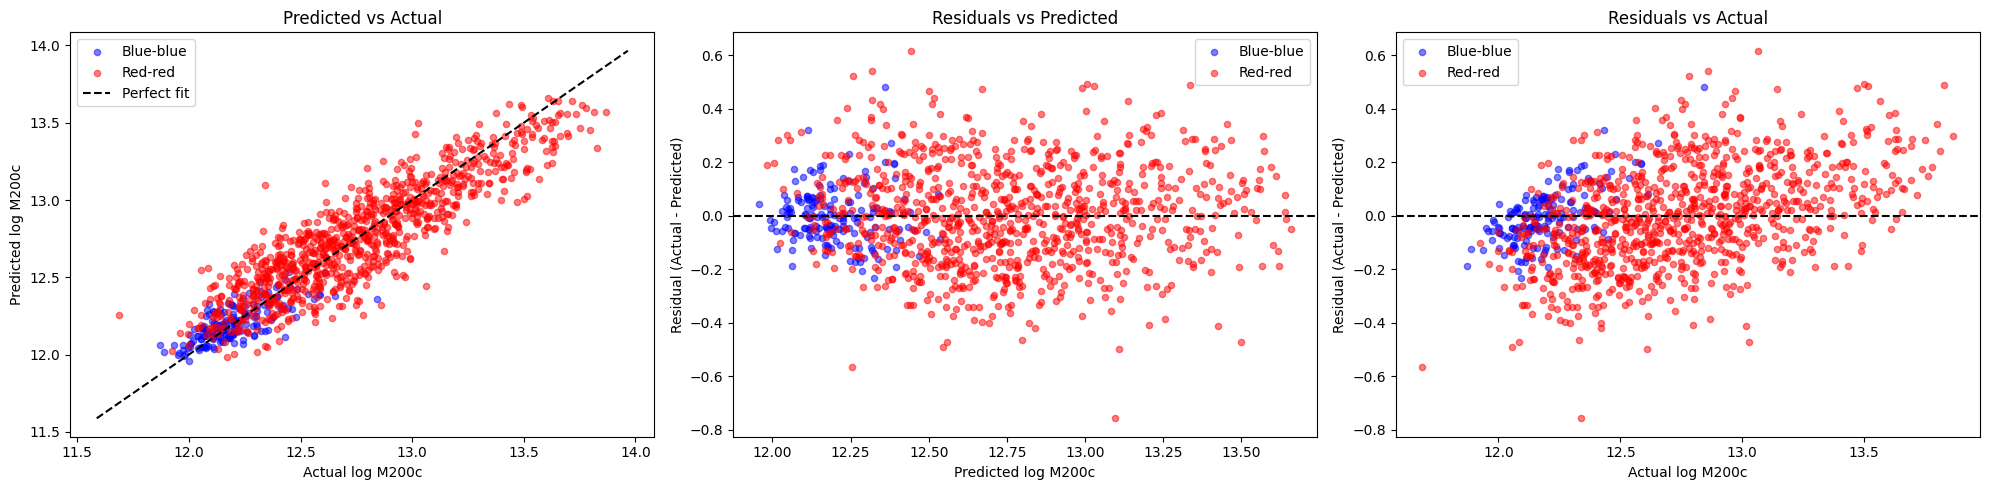

=== Overall ===
R²:   0.827
RMSE: 0.177 dex

Blue-blue R²: 0.539
Red-red R²:   0.782


In [25]:
y_rep = fit.stan_variable('y_rep')
y_pred_mean = y_rep.mean(axis=0)
residuals   = log_m200c - y_pred_mean

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.scatter(log_m200c[group==1], y_pred_mean[group==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(log_m200c[group==2], y_pred_mean[group==2], alpha=0.5, color='red',  label='Red-red',   s=20)
lims = [log_m200c.min()-0.1, log_m200c.max()+0.1]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Predicted log M200c')
ax.set_title('Predicted vs Actual'); ax.legend()

ax = axes[1]
ax.scatter(y_pred_mean[group==1], residuals[group==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_pred_mean[group==2], residuals[group==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log M200c'); ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Predicted'); ax.legend()

ax = axes[2]
ax.scatter(log_m200c[group==1], residuals[group==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(log_m200c[group==2], residuals[group==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title('Residuals vs Actual'); ax.legend()

plt.tight_layout(); plt.show()

print('=== Overall ===')
print(f"R²:   {r2_score(log_m200c, y_pred_mean):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(log_m200c, y_pred_mean)):.3f} dex")
bb = group==1; rr = group==2
print(f"\nBlue-blue R²: {r2_score(log_m200c[bb], y_pred_mean[bb]):.3f}")
print(f"Red-red R²:   {r2_score(log_m200c[rr], y_pred_mean[rr]):.3f}")

## 9. Posterior Coefficients by Group

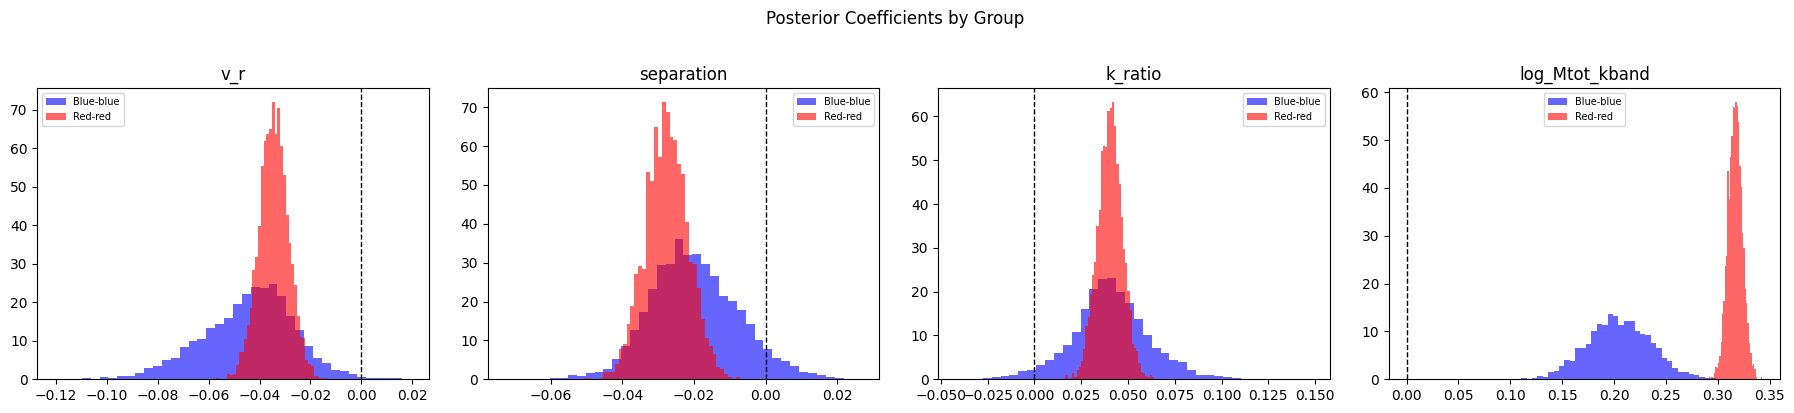

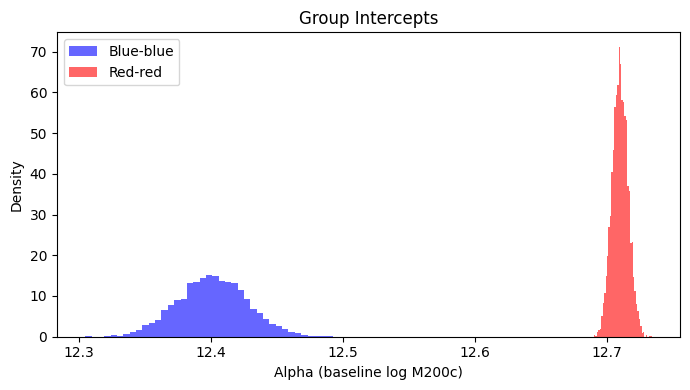

Blue-blue intercept: 12.401 ± 0.027
Red-red intercept:   12.710 ± 0.006
Difference (rr-bb):  0.309 ± 0.027 dex


In [26]:
feature_names = ['v_r', 'separation', 'k_ratio', 'log_Mtot_kband']
beta_samples  = fit.stan_variable('beta')  # (n_samples, 2, 5)
alpha_samples = fit.stan_variable('alpha') # (n_samples, 2)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for k, (ax, name) in enumerate(zip(axes, feature_names)):
    ax.hist(beta_samples[:, 0, k], bins=40, alpha=0.6, color='blue', label='Blue-blue', density=True)
    ax.hist(beta_samples[:, 1, k], bins=40, alpha=0.6, color='red',  label='Red-red',   density=True)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(name); ax.legend(fontsize=7)
plt.suptitle('Posterior Coefficients by Group', y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(alpha_samples[:, 0], bins=40, alpha=0.6, color='blue', label='Blue-blue', density=True)
ax.hist(alpha_samples[:, 1], bins=40, alpha=0.6, color='red',  label='Red-red',   density=True)
ax.set_xlabel('Alpha (baseline log M200c)'); ax.set_ylabel('Density')
ax.set_title('Group Intercepts'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Blue-blue intercept: {alpha_samples[:,0].mean():.3f} ± {alpha_samples[:,0].std():.3f}")
print(f"Red-red intercept:   {alpha_samples[:,1].mean():.3f} ± {alpha_samples[:,1].std():.3f}")
diff = alpha_samples[:,1] - alpha_samples[:,0]
print(f"Difference (rr-bb):  {diff.mean():.3f} ± {diff.std():.3f} dex")

## 10. LOO-CV Model Comparison

In [27]:
loo = az.loo(idata)
print(loo)

Computed from 4000 posterior samples and 1072 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   322.96    24.77
p_loo        8.43        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1072  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



## 11. Local Group Halo Mass Posterior

Using the real LG observables (standardized above), we read out `y_lg_bb` and `y_lg_rr`
from the generated quantities block.

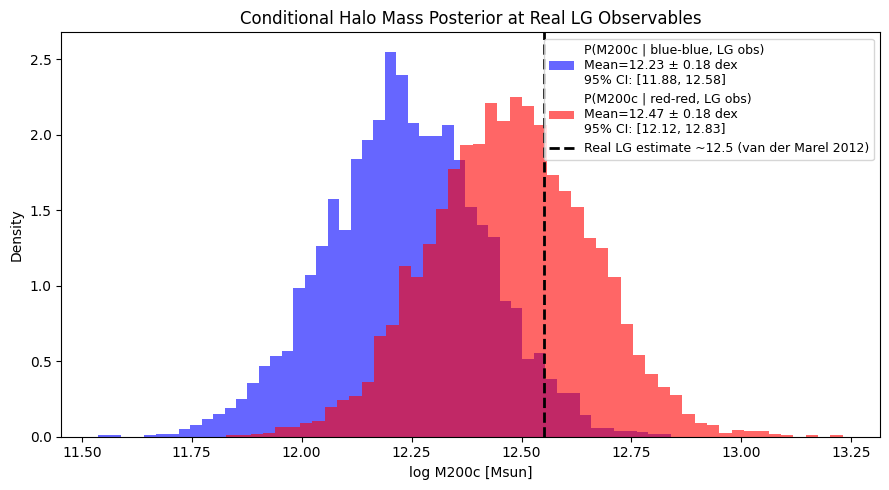

=== Key Result ===
P(log M200c | blue-blue, LG obs) = 12.235 ± 0.178
95% CI: [11.881, 12.581]

P(log M200c | red-red, LG obs)   = 12.473 ± 0.182
95% CI: [12.120, 12.830]

Difference (rr - bb): 0.238 ± 0.255 dex
P(M200c_rr > M200c_bb | LG obs): 0.829


In [28]:
y_lg_bb = fit.stan_variable("y_lg_bb")
y_lg_rr = fit.stan_variable("y_lg_rr")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(y_lg_bb, bins=50, density=True, alpha=0.6, color='blue',
        label=f'P(M200c | blue-blue, LG obs)\n'
              f'Mean={y_lg_bb.mean():.2f} ± {y_lg_bb.std():.2f} dex\n'
              f'95% CI: [{np.percentile(y_lg_bb,2.5):.2f}, {np.percentile(y_lg_bb,97.5):.2f}]')

ax.hist(y_lg_rr, bins=50, density=True, alpha=0.6, color='red',
        label=f'P(M200c | red-red, LG obs)\n'
              f'Mean={y_lg_rr.mean():.2f} ± {y_lg_rr.std():.2f} dex\n'
              f'95% CI: [{np.percentile(y_lg_rr,2.5):.2f}, {np.percentile(y_lg_rr,97.5):.2f}]')

ax.axvline(12.55, color='black', linestyle='--', linewidth=2,
           label='Real LG estimate ~12.5 (van der Marel 2012)')

ax.set_xlabel('log M200c [Msun]')
ax.set_ylabel('Density')
ax.set_title('Conditional Halo Mass Posterior at Real LG Observables')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Key numbers
print("=== Key Result ===")
print(f"P(log M200c | blue-blue, LG obs) = {y_lg_bb.mean():.3f} ± {y_lg_bb.std():.3f}")
print(f"95% CI: [{np.percentile(y_lg_bb,2.5):.3f}, {np.percentile(y_lg_bb,97.5):.3f}]")
print(f"\nP(log M200c | red-red, LG obs)   = {y_lg_rr.mean():.3f} ± {y_lg_rr.std():.3f}")
print(f"95% CI: [{np.percentile(y_lg_rr,2.5):.3f}, {np.percentile(y_lg_rr,97.5):.3f}]")
print(f"\nDifference (rr - bb): {(y_lg_rr - y_lg_bb).mean():.3f} ± {(y_lg_rr - y_lg_bb).std():.3f} dex")
print(f"P(M200c_rr > M200c_bb | LG obs): {(y_lg_rr > y_lg_bb).mean():.3f}")

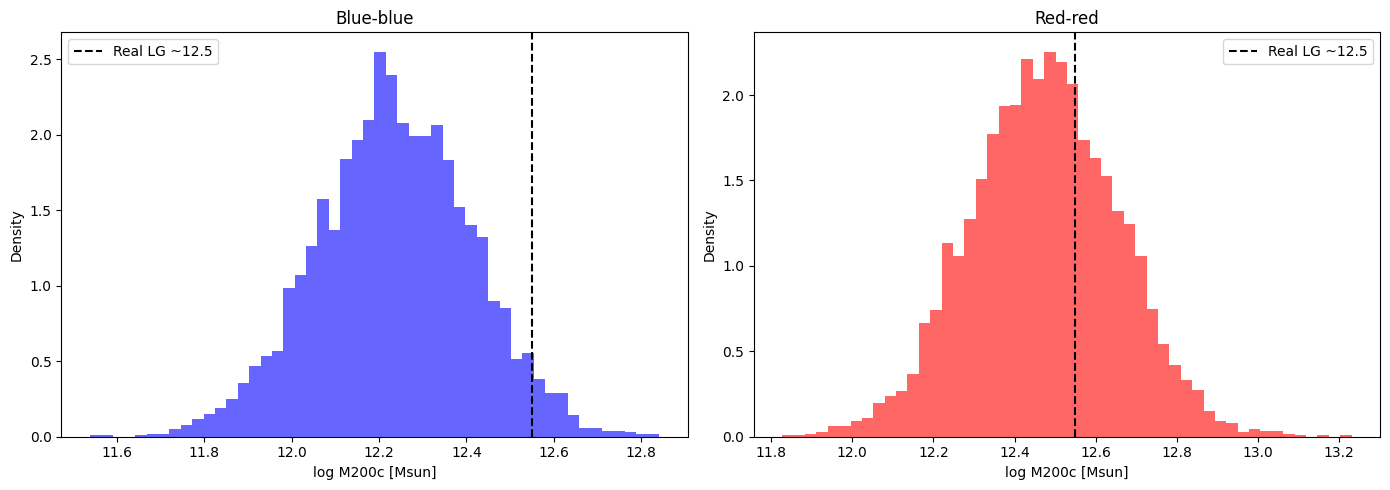

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_lg_bb, bins=50, density=True, color='blue', alpha=0.6)
axes[0].set_title('Blue-blue')
axes[0].set_xlabel('log M200c [Msun]')
axes[0].set_ylabel('Density')
axes[0].axvline(12.55, color='black', linestyle='--', label='Real LG ~12.5')
axes[0].legend()

axes[1].hist(y_lg_rr, bins=50, density=True, color='red', alpha=0.6)
axes[1].set_title('Red-red')
axes[1].set_xlabel('log M200c [Msun]')
axes[1].set_ylabel('Density')
axes[1].axvline(12.55, color='black', linestyle='--', label='Real LG ~12.5')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Train / Test Validation

In [30]:
train_idx, test_idx = train_test_split(
    np.arange(len(log_m200c)),
    test_size=0.2,
    random_state=42,
    stratify=group,
)

X_train, y_train, g_train = X_scaled[train_idx], log_m200c[train_idx], group[train_idx]
X_test,  y_test,  g_test  = X_scaled[test_idx],  log_m200c[test_idx],  group[test_idx]

print(f'Train: {len(train_idx)} pairs  (bb={( g_train==1).sum()}, rr={(g_train==2).sum()})')
print(f'Test:  {len(test_idx)}  pairs  (bb={(g_test==1).sum()},  rr={(g_test==2).sum()})')

stan_data_split = {
    'N_train':     int(len(train_idx)),
    'N_test':      int(len(test_idx)),
    'group_train': g_train.tolist(),
    'group_test':  g_test.tolist(),
    'X_train':     X_train.tolist(),
    'X_test':      X_test.tolist(),
    'y_train':     y_train.tolist(),
    'x_lg':        lg_obs_scaled.tolist(),
}

# fit_2 = model_2.sample(
#     data=stan_data_split,
#     chains=4,
#     parallel_chains=4,
#     iter_sampling=1000,
#     iter_warmup=2000,
#     adapt_delta=0.999,
#     max_treedepth=15,
#     show_progress=True,
# )
# print(fit_2.diagnose())

os.makedirs("saved_fits/modelkband_2", exist_ok=True)

if os.path.exists("saved_fits/modelkband_2") and any(
    f.endswith(".csv") for f in os.listdir("saved_fits/modelkband_2")
):
    print("Loading saved model 2...")
    fit_2 = from_csv("saved_fits/modelkband_2/")
    print("Loaded!")
else:
    print("Fitting model 2...")
    fit_2 = model_2.sample(
        data=stan_data_split,
        chains=4,
        parallel_chains=4,
        iter_sampling=1000,
        iter_warmup=2000,
        adapt_delta=0.999,
        max_treedepth=15,
        show_progress=True,
    )
    for f in fit_2.runset.csv_files:
        shutil.copy(f, "saved_fits/modelkband_2/")
    print("Fitted and saved!")

Train: 857 pairs  (bb=132, rr=725)
Test:  215  pairs  (bb=33,  rr=182)
Fitting model 2...


18:24:47 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]




chain 1:   3%|▎         | 100/3000 [00:12<05:55,  8.16it/s, (Warmup)]




chain 1:   7%|▋         | 200/3000 [00:26<06:19,  7.38it/s, (Warmup)]


chain 1:  10%|█         | 300/3000 [00:44<07:04,  6.37it/s, (Warmup)]


chain 1:  13%|█▎        | 400/3000 [00:54<05:43,  7.58it/s, (Warmup)]

chain 1:  17%|█▋        | 500/3000 [01:08<05:36,  7.43it/s, (Warmup)]


chain 1:  20%|██        | 600/3000 [01:18<04:57,  8.06it/s, (Warmup)]


chain 1:  23%|██▎       | 700/3000 [01:28<04:29,  8.53it/s, (Warmup)]


chain 1:  27%|██▋       | 800/3000 [01:39<04:07,  8.88it/s, (Warmup)]




chain 1:  40%|████      | 1200/3000 [02:18<02:47, 10.74it/s, (Warmup)]


chain 1:  43%|████▎     | 1300/3000 [02:28<02:37, 10.78it/s, (Warmup)]


chain 1:  47%|████▋     | 1400/3000 [02:37<02:28, 10.75it/s, (Warmup)]




chain 1:  50%|█████     | 1500/3000 [02:46<02:19, 10.73it/s, (Warmup)]


chain 1:


18:30:27 - cmdstanpy - INFO - CmdStan done processing.
18:30:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_2_Kband2.stan', line 54, column 8 to line 57, column 10)
	Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_2_Kband2.stan', line 54, column 8 to line 57, column 10)
	Exception: normal_lpdf: Location parameter is nan, but must be finite! (in 'hierarchical_model_2_Kband2.stan', line 54, column 8 to line 57, column 10)
Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_2_Kband2.stan', line 54, column 8 to line 57, column 10)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_2_Kband2.stan', line 54, column 8 to line 57, column 10)
	Exception: normal_lpdf: Location parameter is inf, but must be finite! (in 'hierarchical_model_2_Kband2.stan', lin


Fitted and saved!


In [31]:
print("=== Model 2 diagnostics ===")
print(fit_2.diagnose())

summary_2 = fit_2.summary()
print(summary_2.sort_values('R_hat', ascending=False).head(10)[['R_hat', 'ESS_bulk']])

=== Model 2 diagnostics ===
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

                   R_hat  ESS_bulk
y_rep_test[111]  1.00328   3875.30
log_lik[732]     1.00322   4135.00
log_lik[295]     1.00300   4752.54
log_lik[478]     1.00288   4896.12
log_lik[802]     1.00283   4947.33
log_lik[71]      1.00272   4880.28
log_lik[70]      1.00265   4265.90
log_lik[532]     1.00258   5135.24
log_lik[743]     1.00257   4713.90
log_lik[78]      1.00254   4967.68


## 13. Held-Out Test Set Evaluation

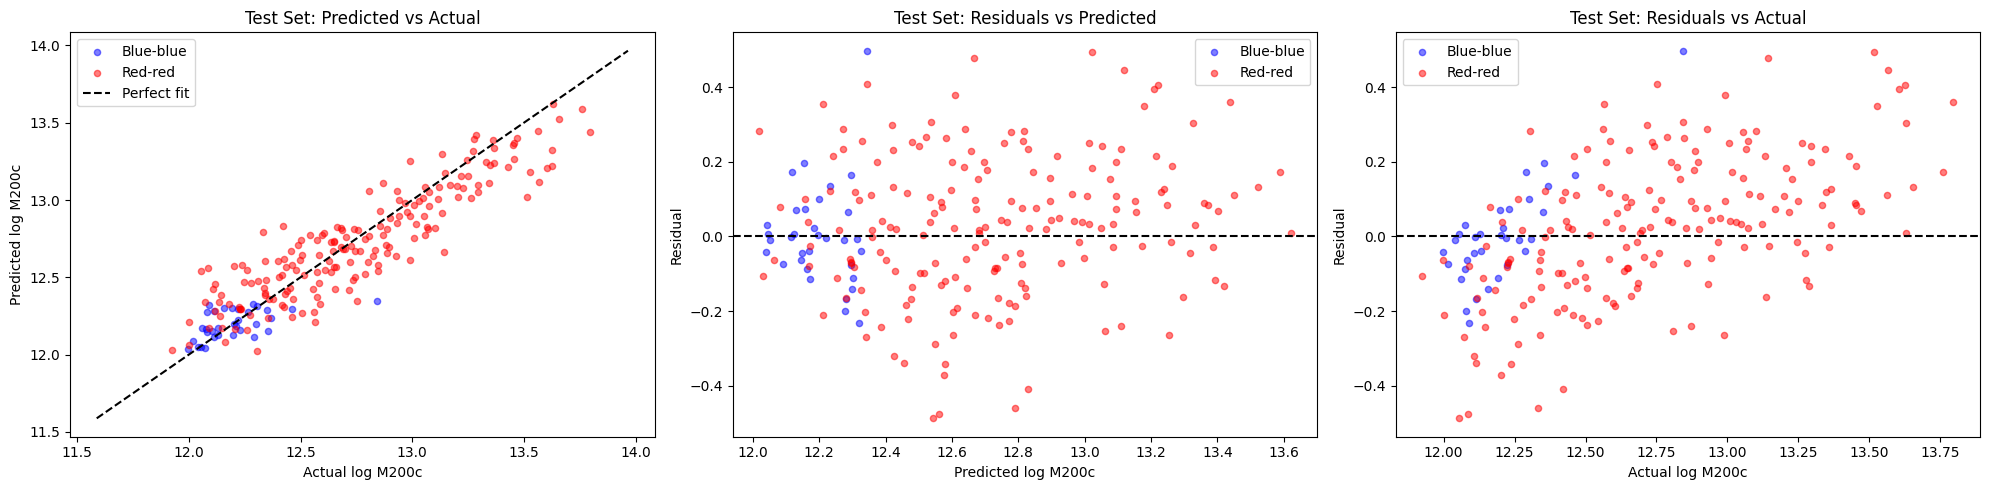

=== Train Set ===
R²:   0.826
RMSE: 0.175 dex

=== Test Set (unseen) ===
R²:   0.826
RMSE: 0.187 dex

Blue-blue R²: 0.310
Red-red R²:   0.794

=== Overfitting Check ===
Train R²: 0.826
Test R²:  0.826
Gap:      0.000  (should be < 0.05)


In [32]:
y_pred_train = fit_2.stan_variable('y_rep_train').mean(axis=0)
y_pred_test  = fit_2.stan_variable('y_rep_test').mean(axis=0)
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test[g_test==1], y_pred_test[g_test==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_test[g_test==2], y_pred_test[g_test==2], alpha=0.5, color='red',  label='Red-red',   s=20)
lims = [log_m200c.min()-0.1, log_m200c.max()+0.1]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Predicted log M200c')
ax.set_title('Test Set: Predicted vs Actual'); ax.legend()

ax = axes[1]
ax.scatter(y_pred_test[g_test==1], residuals_test[g_test==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_pred_test[g_test==2], residuals_test[g_test==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted log M200c'); ax.set_ylabel('Residual')
ax.set_title('Test Set: Residuals vs Predicted'); ax.legend()

ax = axes[2]
ax.scatter(y_test[g_test==1], residuals_test[g_test==1], alpha=0.5, color='blue', label='Blue-blue', s=20)
ax.scatter(y_test[g_test==2], residuals_test[g_test==2], alpha=0.5, color='red',  label='Red-red',   s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual log M200c'); ax.set_ylabel('Residual')
ax.set_title('Test Set: Residuals vs Actual'); ax.legend()

plt.tight_layout(); plt.show()

train_r2 = r2_score(y_train, y_pred_train)
test_r2  = r2_score(y_test,  y_pred_test)
print('=== Train Set ===')
print(f"R²:   {train_r2:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f} dex")
print('\n=== Test Set (unseen) ===')
print(f"R²:   {test_r2:.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f} dex")
print(f"\nBlue-blue R²: {r2_score(y_test[g_test==1], y_pred_test[g_test==1]):.3f}")
print(f"Red-red R²:   {r2_score(y_test[g_test==2], y_pred_test[g_test==2]):.3f}")
print('\n=== Overfitting Check ===')
print(f"Train R²: {train_r2:.3f}")
print(f"Test R²:  {test_r2:.3f}")
print(f"Gap:      {train_r2 - test_r2:.3f}  (should be < 0.05)")

In [33]:
print(f"LG obs scaled: {lg_obs_scaled}")
print(f"Any |z| > 2: {np.abs(lg_obs_scaled) > 2}")

LG obs scaled: [ 0.58245595  0.13026078 -0.05644638 -0.68065684]
Any |z| > 2: [False False False False]
